# **WEEK 2 - EDA**

goal : Use EDA to answer these questions about your dataset before moving to cleaning:
- What is the Residential vs. other property type share?
- What are the median and average close prices?
- What does the Days on Market distribution look like?
- What percentage of homes sold above vs. below list price?
- Are there any apparent date consistency issues (e.g., close date before listing date)?
- Which counties have the highest median prices?

### Set Up

In [11]:
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
import os

DATA_DIR = Path("/Users/kmaxx/Desktop/IDX-da/idx_data")

sold_df = pd.read_csv(DATA_DIR / "combined_sold.csv", low_memory= False)
listing_df = pd.read_csv(DATA_DIR / "combined_listing.csv", low_memory= False)

### What is the Residential vs. other property type share?

In [6]:
import pandas as pd

def residential_share(df):
    summary = (
        df["PropertyType"]
        .eq("Residential")
        .map({True: "Residential", False: "Other"})
        .value_counts()
        .rename_axis("Property Type")
        .reset_index(name="Count")
    )

    summary["Percentage"] = (summary["Count"] / summary["Count"].sum() * 100).round(2)

    return summary

In [12]:
# Sold Data
residential_share(sold_df)

,Property Type,Count,Percentage
0,Residential,384216,67.42
1,Other,185670,32.58


In [13]:
# Listing Data
residential_share(listing_df)

,Property Type,Count,Percentage
0,Residential,567549,58.72
1,Other,398926,41.28


### What are the median and average close prices?

In [14]:
def close_price_summary(df):
    close_price = pd.to_numeric(df["ClosePrice"], errors="coerce")

    summary = pd.DataFrame({
        "Statistic": ["Median Close Price", "Average Close Price"],
        "Value": [
            close_price.median(),
            close_price.mean()
        ]
    })

    return summary

In [15]:
# Sold Data
close_price_summary(sold_df)

,Statistic,Value
0,Median Close Price,630000.000000
1,Average Close Price,880795.751226


In [16]:
# Listing Data
close_price_summary(listing_df)

,Statistic,Value
0,Median Close Price,560000.000000
1,Average Close Price,778945.350235


### What does the Days on Market distribution look like?

In [17]:
import matplotlib.pyplot as plt

def plot_days_on_market(df):
    dom = pd.to_numeric(df["DaysOnMarket"], errors="coerce").dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(dom, bins=50, edgecolor="black")
    plt.title("Distribution of Days on Market")
    plt.xlabel("Days on Market")
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

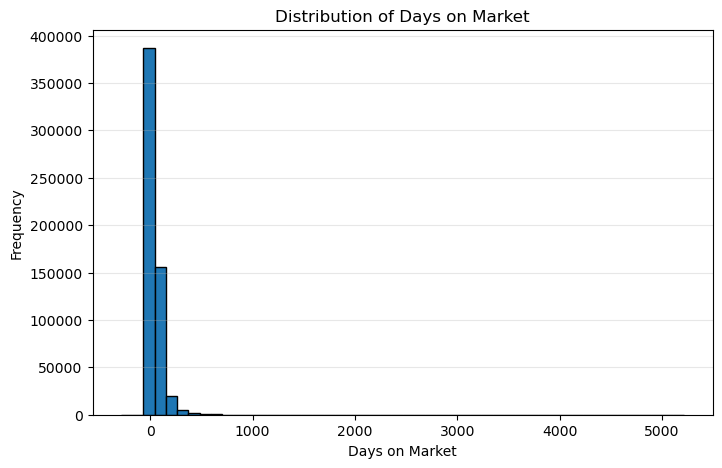

In [18]:
# Sold Data
plot_days_on_market(sold_df)

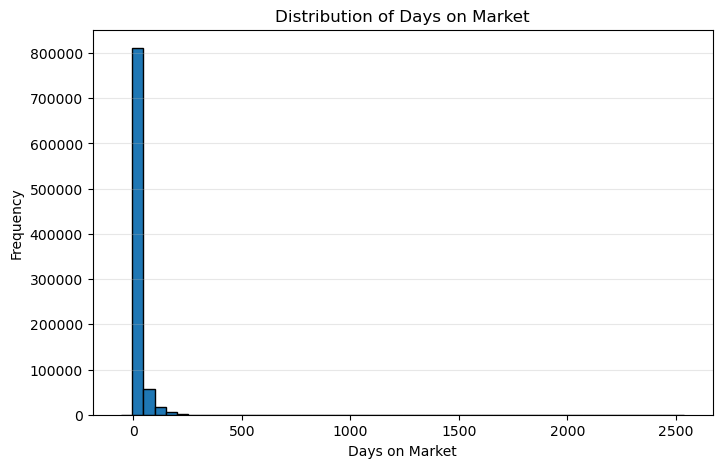

In [19]:
# Listing Data
plot_days_on_market(listing_df)

### What percentage of homes sold above vs. below list price?

In [20]:
def sold_above_below_list_price(df):
    close_price = pd.to_numeric(df["ClosePrice"], errors="coerce")
    list_price = pd.to_numeric(df["ListPrice"], errors="coerce")

    valid = df[close_price.notna() & list_price.notna()].copy()
    valid["Sale_vs_List"] = close_price[valid.index] - list_price[valid.index]

    summary = pd.DataFrame({
        "Category": ["Sold Above List", "Sold At List", "Sold Below List"],
        "Count": [
            (valid["Sale_vs_List"] > 0).sum(),
            (valid["Sale_vs_List"] == 0).sum(),
            (valid["Sale_vs_List"] < 0).sum()
        ]
    })

    summary["Percentage"] = (summary["Count"] / summary["Count"].sum() * 100).round(2)

    return summary

In [21]:
# Sold Data
sold_above_below_list_price(sold_df)

,Category,Count,Percentage
0,Sold Above List,170264,29.92
1,Sold At List,175288,30.81
2,Sold Below List,223448,39.27


In [22]:
# Listing Data
sold_above_below_list_price(listing_df)

,Category,Count,Percentage
0,Sold Above List,71762,30.78
1,Sold At List,89279,38.30
2,Sold Below List,72083,30.92


### Are there any apparent date consistency issues (e.g., close date before listing date)?

In [23]:
def check_date_consistency(df):
    data = df.copy()

    date_cols = [
        "ListingContractDate",
        "PurchaseContractDate",
        "CloseDate",
        "ContractStatusChangeDate"
    ]

    for col in date_cols:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col], errors="coerce")

    issues = {
        "CloseDate before ListingContractDate": (
            data["CloseDate"] < data["ListingContractDate"]
        ).sum(),

        "PurchaseContractDate before ListingContractDate": (
            data["PurchaseContractDate"] < data["ListingContractDate"]
        ).sum(),

        "CloseDate before PurchaseContractDate": (
            data["CloseDate"] < data["PurchaseContractDate"]
        ).sum()
    }

    return pd.DataFrame(
        issues.items(),
        columns=["Issue", "Count"]
    )

In [24]:
# Sold Data
check_date_consistency(sold_df)

,Issue,Count
0,CloseDate before ListingContractDate,110
1,PurchaseContractDate before ListingContractDate,374
2,CloseDate before PurchaseContractDate,302


In [25]:
# Listing Data
check_date_consistency(listing_df)

,Issue,Count
0,CloseDate before ListingContractDate,140
1,PurchaseContractDate before ListingContractDate,406
2,CloseDate before PurchaseContractDate,351


### Which counties have the highest median prices?

In [26]:
def highest_median_price_counties(df, top_n=10):
    data = df.copy()

    data["ClosePrice"] = pd.to_numeric(data["ClosePrice"], errors="coerce")

    county_summary = (
        data.dropna(subset=["CountyOrParish", "ClosePrice"])
        .groupby("CountyOrParish")
        .agg(
            MedianClosePrice=("ClosePrice", "median"),
            AverageClosePrice=("ClosePrice", "mean"),
            Count=("ClosePrice", "count")
        )
        .sort_values("MedianClosePrice", ascending=False)
        .head(top_n)
        .reset_index()
    )

    return county_summary

In [27]:
# Sold Data
highest_median_price_counties(sold_df)

,CountyOrParish,MedianClosePrice,AverageClosePrice,Count
0,Santa Clara,1480000.0,1.741875e+06,18281
1,San Mateo,1451000.0,1.812207e+06,8214
2,Marin,1150000.0,1.280627e+06,159
3,San Francisco,1100000.0,1.179005e+06,1166
4,Alameda,1050000.0,1.274277e+06,21060
5,Santa Cruz,1039500.0,1.209080e+06,3464
6,Monterey,875000.0,1.330818e+06,4171
7,San Diego,810000.0,1.240398e+06,61132
8,San Luis Obispo,785000.0,8.713856e+05,7557
9,San Benito,766500.0,8.238833e+05,862


In [28]:
# Listing Data
highest_median_price_counties(listing_df)

,CountyOrParish,MedianClosePrice,AverageClosePrice,Count
0,Santa Clara,1525000.0,1.761217e+06,8680
1,San Mateo,1452000.0,1.781417e+06,4047
2,Marin,1188500.0,1.334412e+06,68
3,San Francisco,1125000.0,1.185162e+06,544
4,Alameda,1085000.0,1.200965e+06,9358
5,Santa Cruz,1082500.0,1.219941e+06,1392
6,Monterey,899000.0,1.349821e+06,1584
7,San Diego,780000.0,1.047241e+06,25971
8,San Luis Obispo,755500.0,8.141435e+05,2386
9,Contra Costa,755250.0,9.763400e+05,9152
